In [ ]:
!pip install xgboost -q

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


#Dataset Imported

In [ ]:
import pandas as pd
import numpy as np

data = pd.read_csv('/content/drive/MyDrive/ML Models DataSet/simple_ARES.csv')

print("Dataset Shape: ",data.shape)
print("\nColumns: ",data.columns.tolist())

data.head()
data.describe()

Dataset Shape:  (50000, 13)

Columns:  ['AREAMQZM1.k1   ', 'AREAMQZM2.k1   ', 'AREAMCVM1.angle', 'AREAMQZM3.k1   ', 'AREAMCHM1.angle', 'mu_x', 'mu_y', 'sigma_x', 'sigma_y', 'unbiasedbeam', 'smallbeamx', 'smallbeamy', 'is_good_beam']


,AREAMQZM1.k1,AREAMQZM2.k1,AREAMCVM1.angle,AREAMQZM3.k1,AREAMCHM1.angle,mu_x,mu_y,sigma_x,sigma_y
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,5.000000e+04,5.000000e+04
mean,-0.006864,-0.077816,-0.000003,0.112448,0.000011,0.000005,-0.000004,7.188966e-06,2.574726e-05
std,17.303816,17.310415,0.003558,17.319702,0.003560,0.001602,0.003789,9.168300e-06,3.358026e-05
min,-29.999146,-29.996248,-0.006178,-29.998823,-0.006178,-0.002780,-0.010368,3.461239e-08,3.426062e-08
25%,-15.011083,-15.007791,-0.003070,-14.957683,-0.003062,-0.001378,-0.002544,1.854920e-06,6.148033e-06
50%,0.069283,-0.138175,0.000012,0.234025,0.000034,0.000015,0.000010,4.007045e-06,1.420050e-05
75%,14.959006,14.889754,0.003055,15.133965,0.003089,0.001390,0.002530,8.133332e-06,2.934626e-05
max,29.998138,29.999626,0.006178,29.999039,0.006178,0.002780,0.010383,8.326272e-05,3.071321e-04


Splitting data in train and test data

In [ ]:
from sklearn.model_selection import train_test_split

TARGET = ['mu_x','mu_y','sigma_x','sigma_y']
Unnecessary = ['unbiasedbeam', 'smallbeamx', 'smallbeamy', 'is_good_beam']

data = data.drop(columns=Unnecessary)
X = data.drop(columns=TARGET)
y = data[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))

Training Samples: 40000
Testing Samples: 10000


#Training Model

In [ ]:
from sklearn.multioutput import MultiOutputRegressor
from xgboost import XGBRegressor

model = MultiOutputRegressor(
  XGBRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
  )
)

model.fit(X_train, y_train)

print("Training Complete!")

Training Complete!


#Evaluating

In [ ]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

predictions = model.predict(X_test)

for i, target in enumerate(y.columns):

    mae = mean_absolute_error(
        y_test.iloc[:, i],
        predictions[:, i]
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test.iloc[:, i],
            predictions[:, i]
        )
    )

    r2 = r2_score(
        y_test.iloc[:, i],
        predictions[:, i]
    )

    print("\n" + "-"*50)
    print(f"Performance for {target}")
    print("-"*50)

    print("Mean Absolute Error    :", mae)
    print("Root Mean Square Error :", rmse)
    print("R² Score               :", r2)


--------------------------------------------------
Performance for mu_x
--------------------------------------------------
Mean Absolute Error    : 1.0358043196400907e-05
Root Mean Square Error : 1.4831350784627593e-05
R² Score               : 0.9999145149319894

--------------------------------------------------
Performance for mu_y
--------------------------------------------------
Mean Absolute Error    : 4.443158822645734e-05
Root Mean Square Error : 6.58104827765891e-05
R² Score               : 0.9996991883267489

--------------------------------------------------
Performance for sigma_x
--------------------------------------------------
Mean Absolute Error    : 5.8937017210387295e-06
Root Mean Square Error : 8.855563965981209e-06
R² Score               : -0.0006000218559139014

--------------------------------------------------
Performance for sigma_y
--------------------------------------------------
Mean Absolute Error    : 1.2723267901505902e-05
Root Mean Square Error : 1.890

Feature Importance analyses

In [ ]:
for i, target in enumerate(y.columns):

    print(f"\n{'='*50}")
    print(f"Feature Importance for {target}")
    print(f"{'='*50}")

    importance = pd.DataFrame({
        "Feature": X.columns,
        "Importance": model.estimators_[i].feature_importances_
    })

    importance = importance.sort_values(
        by="Importance",
        ascending=False
    )

    print(importance.head(20))


Feature Importance for mu_x
           Feature  Importance
4  AREAMCHM1.angle    0.956645
3  AREAMQZM3.k1       0.011788
1  AREAMQZM2.k1       0.010948
0  AREAMQZM1.k1       0.010500
2  AREAMCVM1.angle    0.010119

Feature Importance for mu_y
           Feature  Importance
2  AREAMCVM1.angle    0.818980
3  AREAMQZM3.k1       0.143227
1  AREAMQZM2.k1       0.012731
0  AREAMQZM1.k1       0.012731
4  AREAMCHM1.angle    0.012332

Feature Importance for sigma_x
           Feature  Importance
0  AREAMQZM1.k1            0.0
1  AREAMQZM2.k1            0.0
2  AREAMCVM1.angle         0.0
3  AREAMQZM3.k1            0.0
4  AREAMCHM1.angle         0.0

Feature Importance for sigma_y
           Feature  Importance
0  AREAMQZM1.k1       0.343863
1  AREAMQZM2.k1       0.341927
3  AREAMQZM3.k1       0.314210
2  AREAMCVM1.angle    0.000000
4  AREAMCHM1.angle    0.000000


<Figure size 1200x500 with 0 Axes>

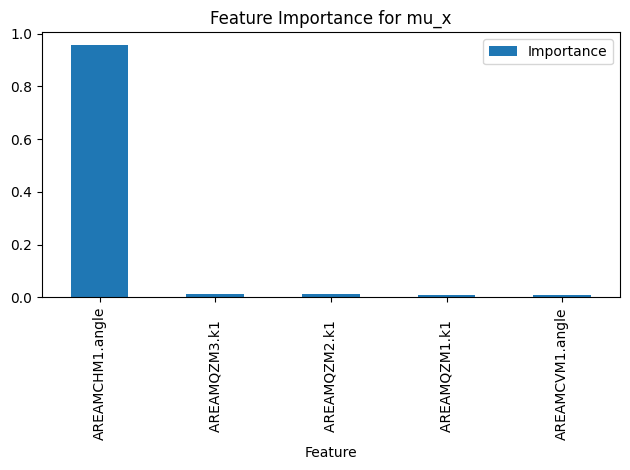

<Figure size 1200x500 with 0 Axes>

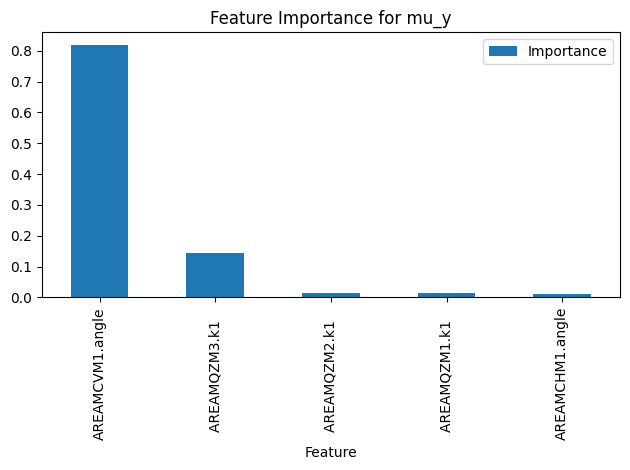

<Figure size 1200x500 with 0 Axes>

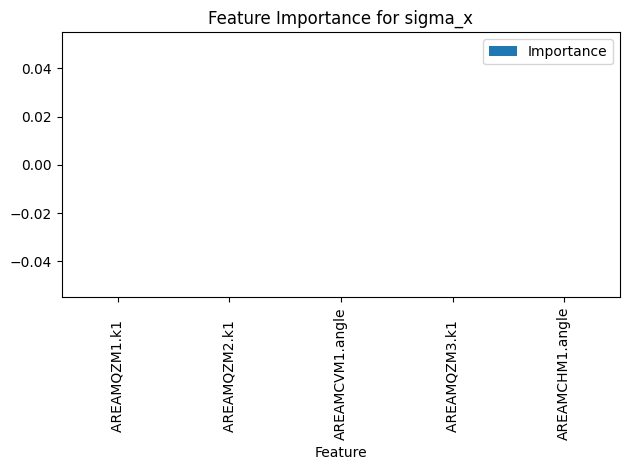

<Figure size 1200x500 with 0 Axes>

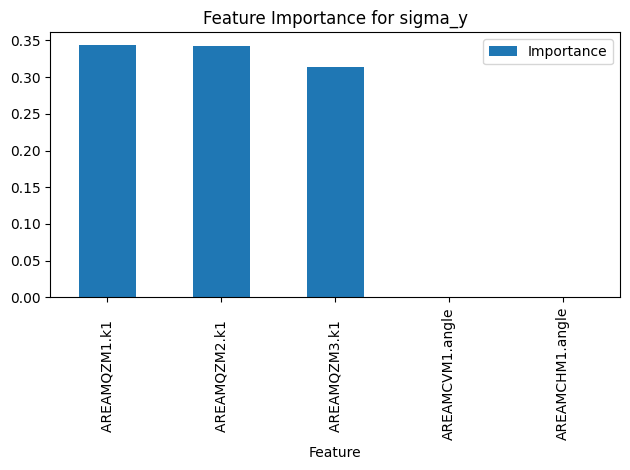

In [ ]:
import matplotlib.pyplot as plt

for i, target in enumerate(y.columns):

    importance = pd.DataFrame({
        "Feature": X.columns,
        "Importance": model.estimators_[i].feature_importances_
    })

    importance = importance.sort_values(
        by="Importance",
        ascending=False
    )

    plt.figure(figsize=(12,5))

    importance.head(15).plot(
        x="Feature",
        y="Importance",
        kind="bar"
    )

    plt.title(f"Feature Importance for {target}")
    plt.tight_layout()
    plt.show()

#Save Model

In [ ]:
import joblib

joblib.dump(model, "beam_regression_model.pkl")

print("Model Saved!")

Model Saved!


In [ ]:
from google.colab import files

files.download("beam_regression_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

#Actual Model

In [ ]:
sample = X_test.iloc[[1000]]

prediction = model.predict(sample)

print("Predictions:")
print("-"*25)
print("mu_x    =", prediction[0][0])
print("mu_y    =", prediction[0][1])
print("sigma_x =", prediction[0][2])
print("sigma_y =", prediction[0][3])

print("\nActual Values:")
print("-"*25)
print(y_test.iloc[1000])

Predictions:
-------------------------
mu_x    = -0.0020632248
mu_y    = 0.008562598
sigma_x = 7.235168e-06
sigma_y = 4.17696e-05

Actual Values:
-------------------------
mu_x      -0.002125
mu_y       0.008623
sigma_x    0.000004
sigma_y    0.000053
Name: 12950, dtype: float64
